# <b>Climate Impacts on Fish Stocks Analysis Capstone Project</b>
Author: Daisy Chu
<br>Date: 3/10/2026</br>
## Environmental Research Question: 
- How does ocean temperature and salinity impact number of fish landings in Portugal?

Link to GitHub repository: [GitHub Repository](<https://github.com/daisychu12/pt-fisheries-climate-change>)

## Final Analysis and Visualizations

### Load Libraries and Processed Datasets

In [4]:
# Load libraries
library(dplyr)
library(ggplot2)
library(tidyverse)
library(ggpubr)
library(Hmisc)
library(caret)


Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
✔ readr     2.1.5     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


...

The following objects are masked from ‘package:dplyr’:

    src, summarize




The following objects are masked from ‘package:base’:

    format.pval, units




Loading required package: lattice




Attaching package: ‘caret’




The following object is masked from ‘package:purrr’:

    lift




In [5]:
# Set working dir to processed data folder
setwd("../data/processed_data")
list.files()

[1] "atl_cod.csv"            "bl_jack.csv"            "clim_and_cost.csv"     
[4] "common_oct.csv"         "horse_mack.csv"         "pt_annual_landings.csv"
[7] "README.md"              "sardine.csv"            "top_5_landings.csv"

In [30]:
# Load datasets
atl_cod <- read.csv("atl_cod.csv")
bl_jack <- read.csv("bl_jack.csv")
common_oct <- read.csv("common_oct.csv")
horse_mack <- read.csv("horse_mack.csv")
top_5_landings <- read.csv("top_5_landings.csv")
pt_annual_landings <- read.csv("pt_annual_landings.csv")
clim_and_cost <- read.csv("clim_and_cost.csv")
sardine <- read.csv("sardine.csv")

In [32]:
# Create a dataframe for total landings of all species and annual fish cost
landings_price <- pt_annual_landings %>%
  group_by(year) %>%
  summarise(sum_landings = sum(total_landings)) %>%
  left_join(clim_and_cost, by = "year") %>%
  select(year, sum_landings, price) %>%
  drop_na()

head(landings_price)

year,sum_landings,price
<int>,<dbl>,<dbl>
2011,450202.7,1.67
2012,384841.8,1.81
2013,378927.3,1.70
2014,326861.0,2.02
2015,327649.9,1.81
2016,346359.9,2.10


### Correlation Analysis on Fish Landings and Cost and Temperature

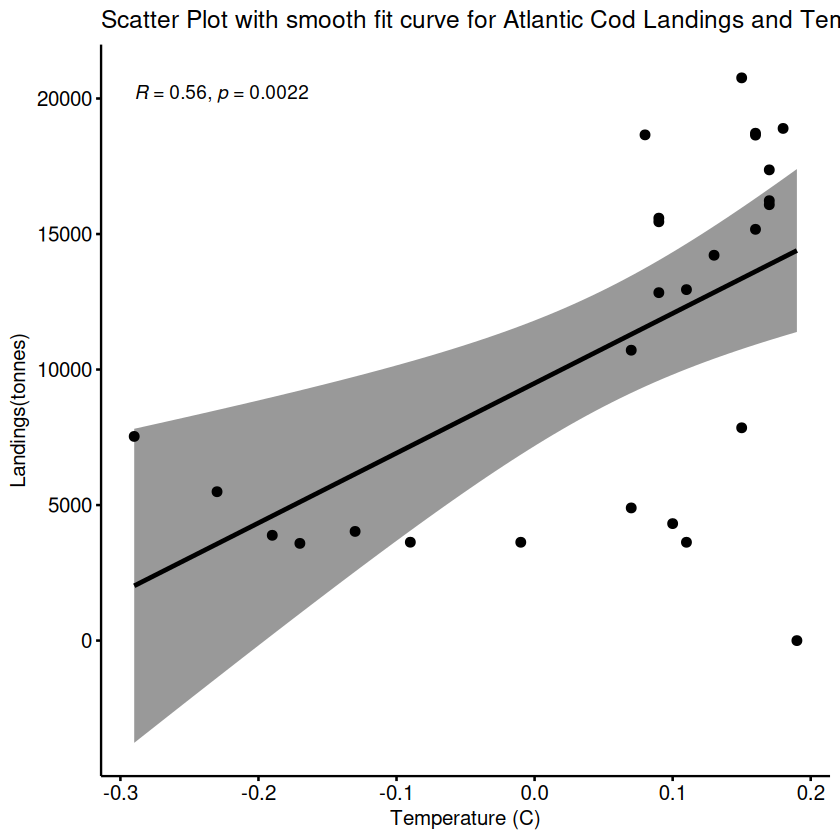

In [8]:
# Conduct and Plot Correlation Analysis on Atlantic Cod
ggscatter(atl_cod, x = "max_temp", y = "total_landings", 
          add = "reg.line", conf.int = TRUE, 
          cor.coef = TRUE, cor.method = "pearson",
          title = "Scatter Plot with smooth fit curve for Atlantic Cod Landings and Temp",
          xlab = "Temperature (C)", ylab = "Landings(tonnes)")

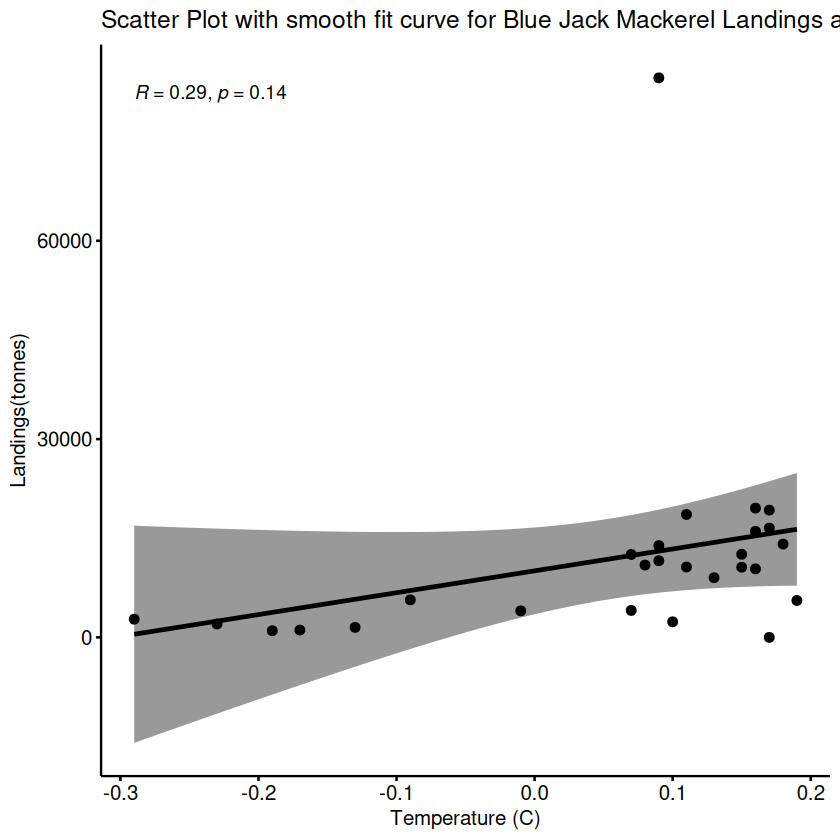

In [9]:
# Conduct and Plot Correlation Analysis on Blue Jack Mackerel
ggscatter(bl_jack, x = "max_temp", y = "total_landings", 
          add = "reg.line", conf.int = TRUE, 
          cor.coef = TRUE, cor.method = "pearson",
          title = "Scatter Plot with smooth fit curve for Blue Jack Mackerel Landings and Temp",
          xlab = "Temperature (C)", ylab = "Landings(tonnes)")

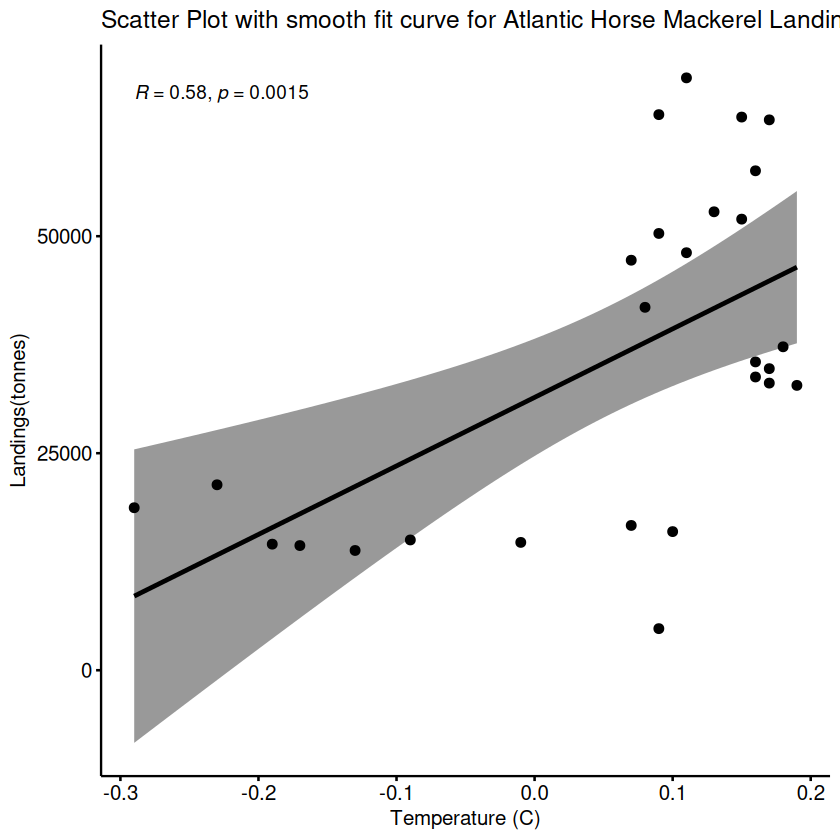

In [10]:
# Conduct and Plot Correlation Analysis on Atlantic Horse Mackerel
ggscatter(horse_mack, x = "max_temp", y = "total_landings", 
          add = "reg.line", conf.int = TRUE, 
          cor.coef = TRUE, cor.method = "pearson",
          title = "Scatter Plot with smooth fit curve for Atlantic Horse Mackerel Landings and Temp",
          xlab = "Temperature (C)", ylab = "Landings(tonnes)")

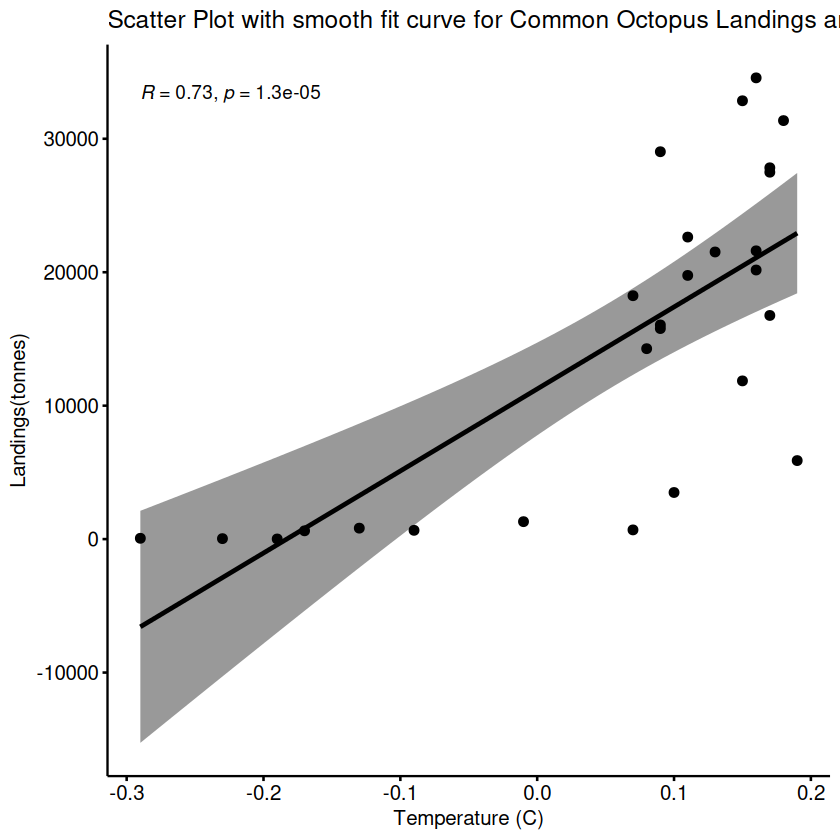

In [11]:
# Conduct and Plot Correlation Analysis on Common Octopus
ggscatter(common_oct, x = "max_temp", y = "total_landings", 
          add = "reg.line", conf.int = TRUE, 
          cor.coef = TRUE, cor.method = "pearson",
          title = "Scatter Plot with smooth fit curve for Common Octopus Landings and Temp",
          xlab = "Temperature (C)", ylab = "Landings(tonnes)")

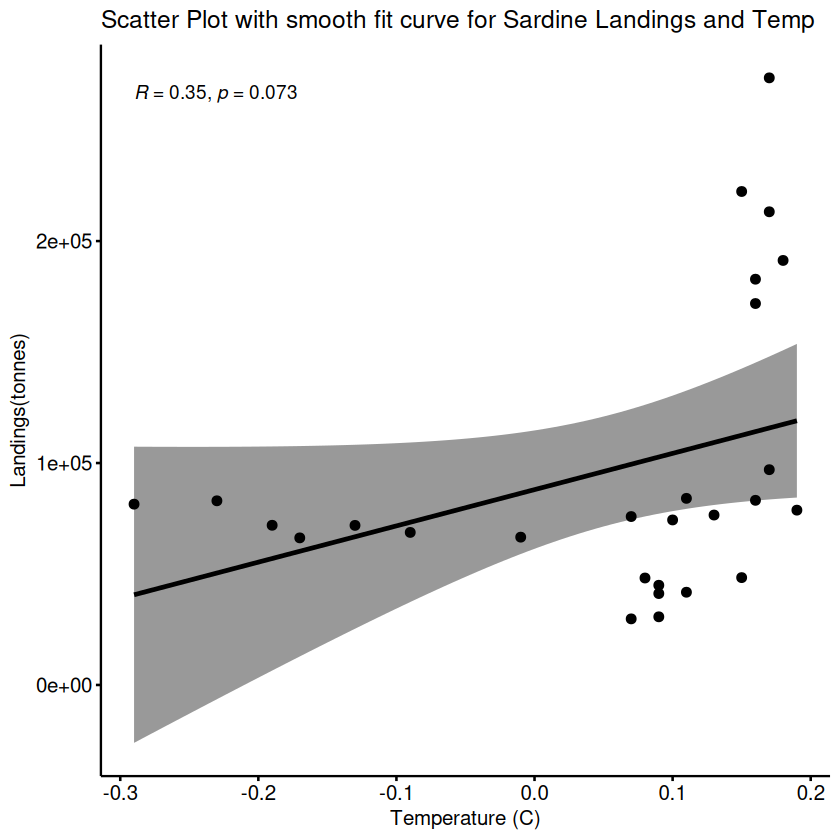

In [12]:
# Conduct and Plot Correlation Analysis on Sardine
ggscatter(sardine, x = "max_temp", y = "total_landings", 
          add = "reg.line", conf.int = TRUE, 
          cor.coef = TRUE, cor.method = "pearson",
          title = "Scatter Plot with smooth fit curve for Sardine Landings and Temp",
          xlab = "Temperature (C)", ylab = "Landings(tonnes)")

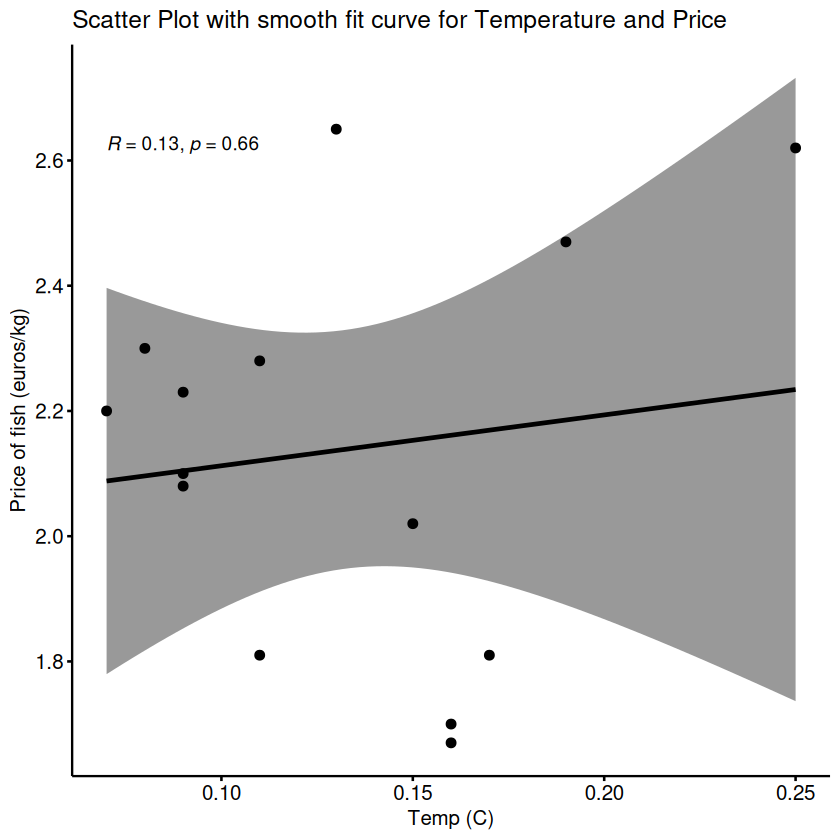

In [13]:
# Conduct and Plot Correlation Analysis on Climate and Cost
ggscatter(clim_and_cost, x = "max_temp", y = "price", 
          add = "reg.line", conf.int = TRUE, 
          cor.coef = TRUE, cor.method = "pearson",
          title = "Scatter Plot with smooth fit curve for Temperature and Price",
          xlab = "Temp (C)", ylab = "Price of fish (euros/kg)")

Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_smooth()`).”


Warning message:
“Removed 14 rows containing non-finite outside the scale range (`stat_cor()`).”


Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`).”


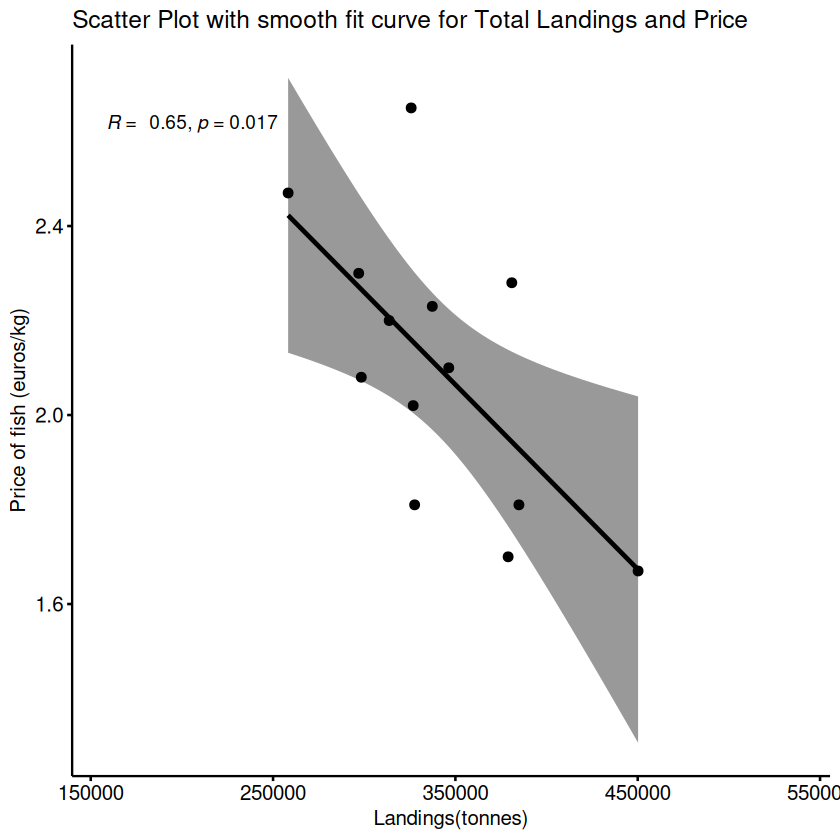

In [14]:
# Conduct and Plot Correlation Analysis on Landings and Cost
ggscatter(landings_price, x = "sum_landings", y = "price", 
          add = "reg.line", conf.int = TRUE, 
          cor.coef = TRUE, cor.method = "pearson",
          title = "Scatter Plot with smooth fit curve for Total Landings and Price",
          xlab = "Landings(tonnes)", ylab = "Price of fish (euros/kg)")

### Regression Analysis on Fish Landings and Cost and Temperature


Call:
lm(formula = max_temp ~ poly(total_landings, 2), data = atl_cod)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.27529 -0.07458  0.01528  0.06194  0.19937 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)   
(Intercept)               0.05519    0.02266   2.435  0.02268 * 
poly(total_landings, 2)1  0.40339    0.11774   3.426  0.00221 **
poly(total_landings, 2)2  0.13423    0.11774   1.140  0.26553   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1177 on 24 degrees of freedom
Multiple R-squared:  0.352,	Adjusted R-squared:  0.298 
F-statistic: 6.518 on 2 and 24 DF,  p-value: 0.005482


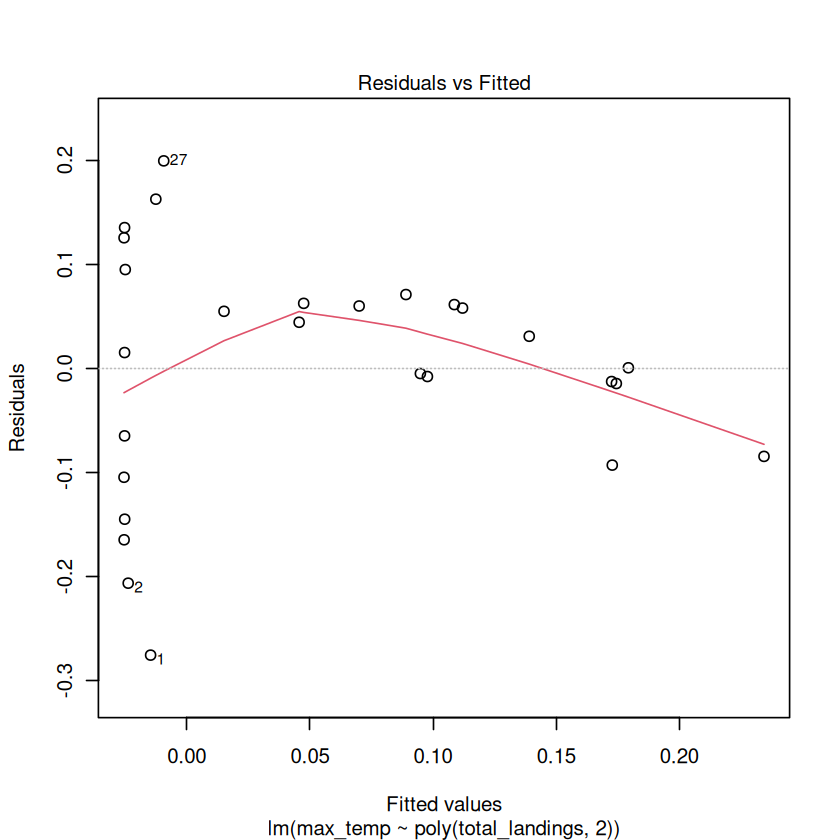

In [15]:
# Regression Analysis on Temperature and Atlantic Cod Landings
atl_cod_mod <- lm(max_temp ~ poly(total_landings, 2), data=atl_cod)

# Print summary of results
summary(atl_cod_mod)

# Plot Residuals vs Fitted
plot(atl_cod_mod, 1)


Call:
lm(formula = max_temp ~ poly(total_landings, 2), data = bl_jack)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.247745 -0.053300  0.002939  0.057004  0.262068 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)    
(Intercept)               0.05519    0.02128   2.594 0.015936 *  
poly(total_landings, 2)1  0.21115    0.11056   1.910 0.068185 .  
poly(total_landings, 2)2 -0.41893    0.11056  -3.789 0.000896 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1106 on 24 degrees of freedom
Multiple R-squared:  0.4286,	Adjusted R-squared:  0.381 
F-statistic: 9.002 on 2 and 24 DF,  p-value: 0.001211


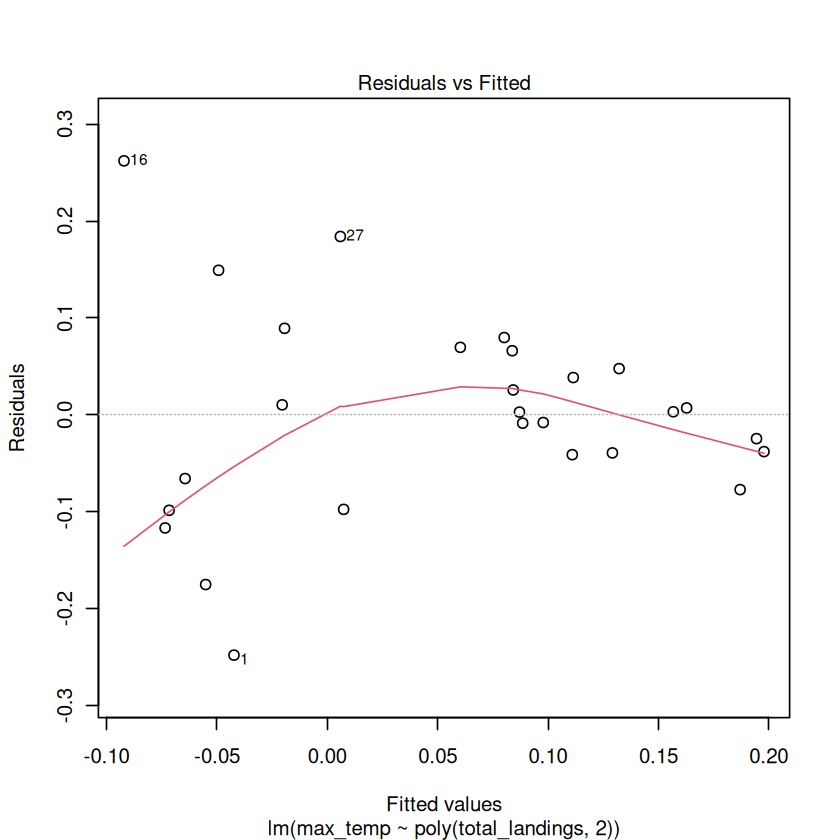

In [16]:
# Regression Analysis on Temperature and Blue Jack Mackerel Landings
bl_jack_mod <- lm(max_temp ~ poly(total_landings, 2), data=bl_jack)

# Print summary of results
summary(bl_jack_mod)

# Plot Residuals vs Fitted
plot(bl_jack_mod, 1)


Call:
lm(formula = max_temp ~ total_landings, data = horse_mack)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.272037 -0.070200  0.001854  0.109690  0.167654 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)   
(Intercept)    -9.819e-02  4.841e-02  -2.028  0.05332 . 
total_landings  4.286e-06  1.199e-06   3.575  0.00146 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1166 on 25 degrees of freedom
Multiple R-squared:  0.3383,	Adjusted R-squared:  0.3119 
F-statistic: 12.78 on 1 and 25 DF,  p-value: 0.001461


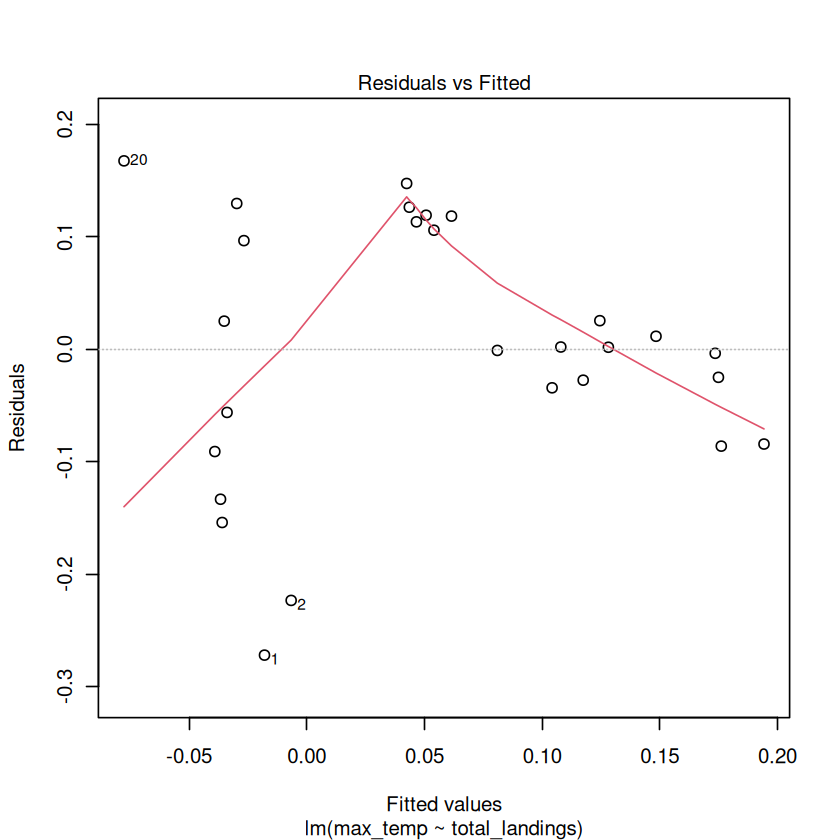

In [17]:
# Regression Analysis on Temperature and Atlantic Horse Mackerel Landings
horse_mack_mod <- lm(max_temp ~ total_landings, data=horse_mack)

# Print summary of results
summary(horse_mack_mod)

# Plot Residuals vs Fitted
plot(horse_mack_mod, 1)


Call:
lm(formula = max_temp ~ poly(total_landings, 2), data = common_oct)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.176614 -0.044284  0.003526  0.037702  0.189700 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)    
(Intercept)               0.05519    0.01638   3.369  0.00254 ** 
poly(total_landings, 2)1  0.52634    0.08512   6.184 2.17e-06 ***
poly(total_landings, 2)2 -0.25014    0.08512  -2.939  0.00717 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.08512 on 24 degrees of freedom
Multiple R-squared:  0.6614,	Adjusted R-squared:  0.6332 
F-statistic: 23.44 on 2 and 24 DF,  p-value: 2.273e-06


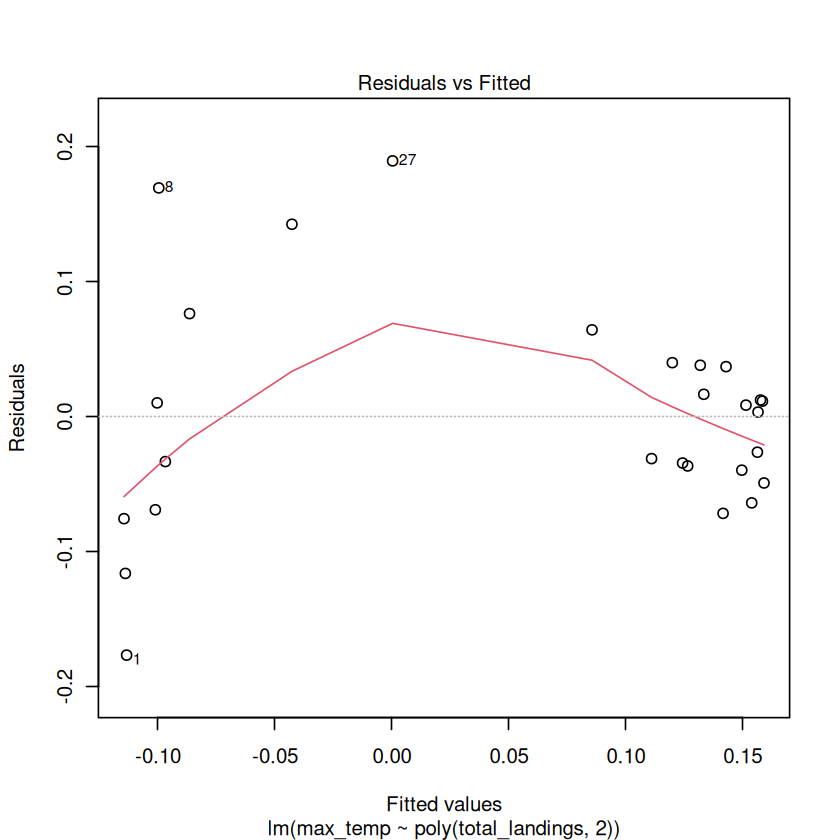

In [22]:
# Regression Analysis on Temperature and Common Octopus Landings
common_oct_mod <- lm(max_temp ~ poly(total_landings, 2), data=common_oct)

# Print summary of results
summary(common_oct_mod)

# Plot Residuals vs Fitted
plot(common_oct_mod, 1)


Call:
lm(formula = max_temp ~ poly(total_landings, 2), data = sardine)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.31907 -0.06244  0.05154  0.07594  0.16116 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)  
(Intercept)               0.05519    0.02600   2.123   0.0443 *
poly(total_landings, 2)1  0.25154    0.13510   1.862   0.0749 .
poly(total_landings, 2)2  0.11029    0.13510   0.816   0.4223  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1351 on 24 degrees of freedom
Multiple R-squared:  0.1469,	Adjusted R-squared:  0.07583 
F-statistic: 2.067 on 2 and 24 DF,  p-value: 0.1486


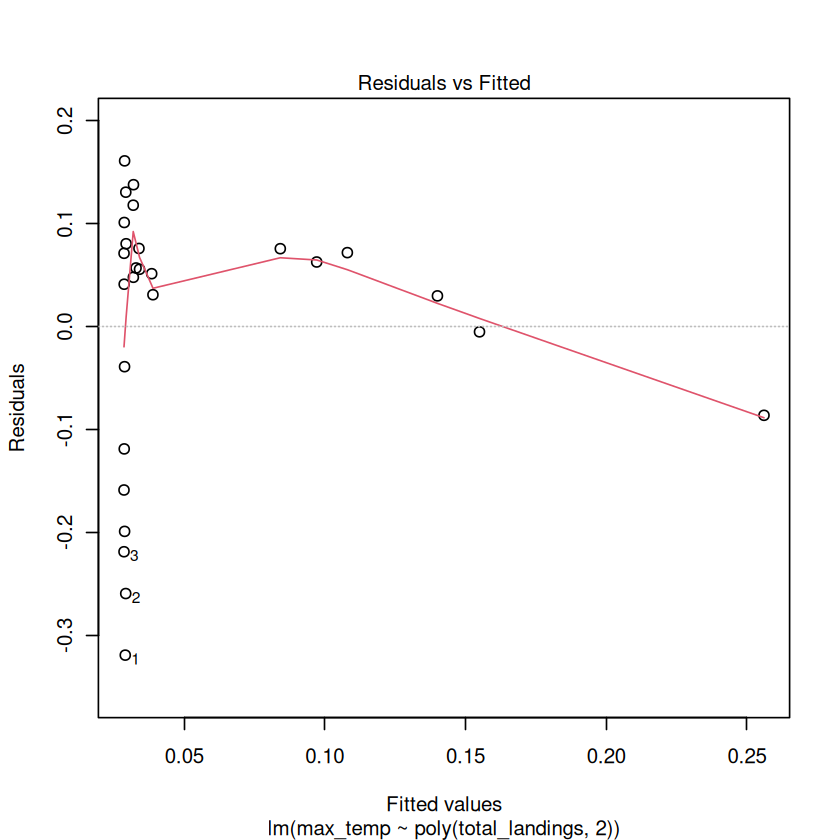

In [33]:
# Regression Analysis on Temperature and Sardine Landings
sardine_mod <- lm(max_temp ~ poly(total_landings, 2), data=sardine)

# Print summary of results
summary(sardine_mod)

# Plot Residuals vs Fitted
plot(sardine_mod, 1)


Call:
lm(formula = max_temp ~ poly(price, 2), data = clim_and_cost)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.068709 -0.020606 -0.009002  0.028195  0.062318 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)      0.13214    0.01062  12.437 8.05e-08 ***
poly(price, 2)1  0.02373    0.03975   0.597  0.56263    
poly(price, 2)2  0.12445    0.03975   3.130  0.00957 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.03975 on 11 degrees of freedom
Multiple R-squared:  0.4801,	Adjusted R-squared:  0.3855 
F-statistic: 5.078 on 2 and 11 DF,  p-value: 0.0274


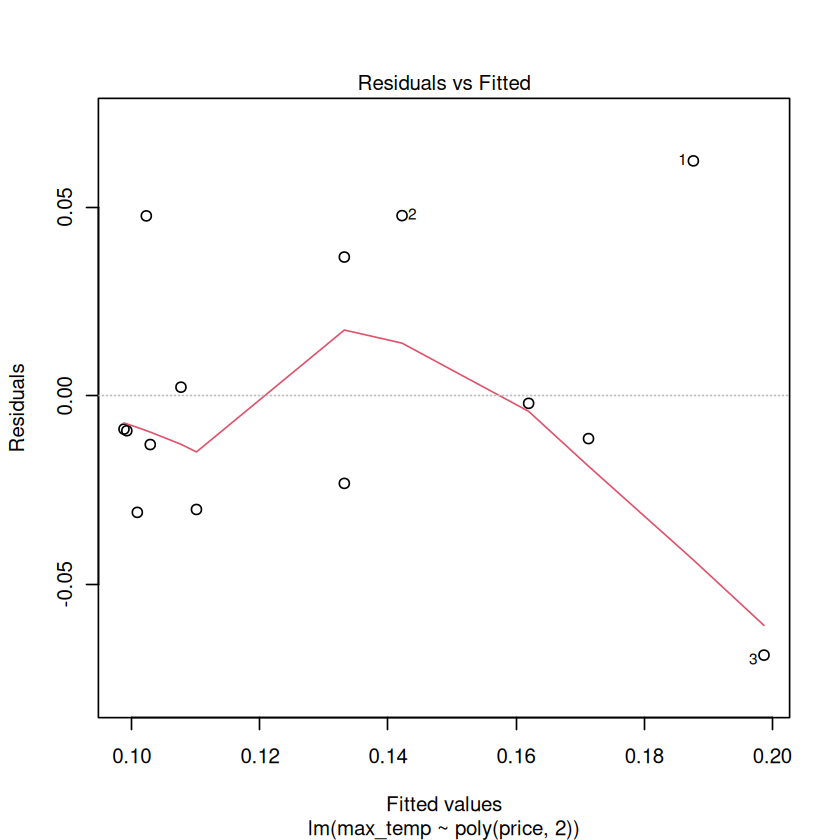

In [27]:
# Regression Analysis on Temperature and Fish Cost
clim_cost_mod <- lm(max_temp ~ poly(price, 2), data=clim_and_cost)

# Print summary of results
summary(clim_cost_mod)

# Plot Residuals vs Fitted
plot(clim_cost_mod, 1)


Call:
lm(formula = sum_landings ~ price, data = landings_price)

Residuals:
   Min     1Q Median     3Q    Max 
-44377 -22356  -4337  13300  63742 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   564424      80687   6.995 2.28e-05 ***
price        -106565      38045  -2.801   0.0172 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 39140 on 11 degrees of freedom
  (14 observations deleted due to missingness)
Multiple R-squared:  0.4163,	Adjusted R-squared:  0.3632 
F-statistic: 7.846 on 1 and 11 DF,  p-value: 0.01724


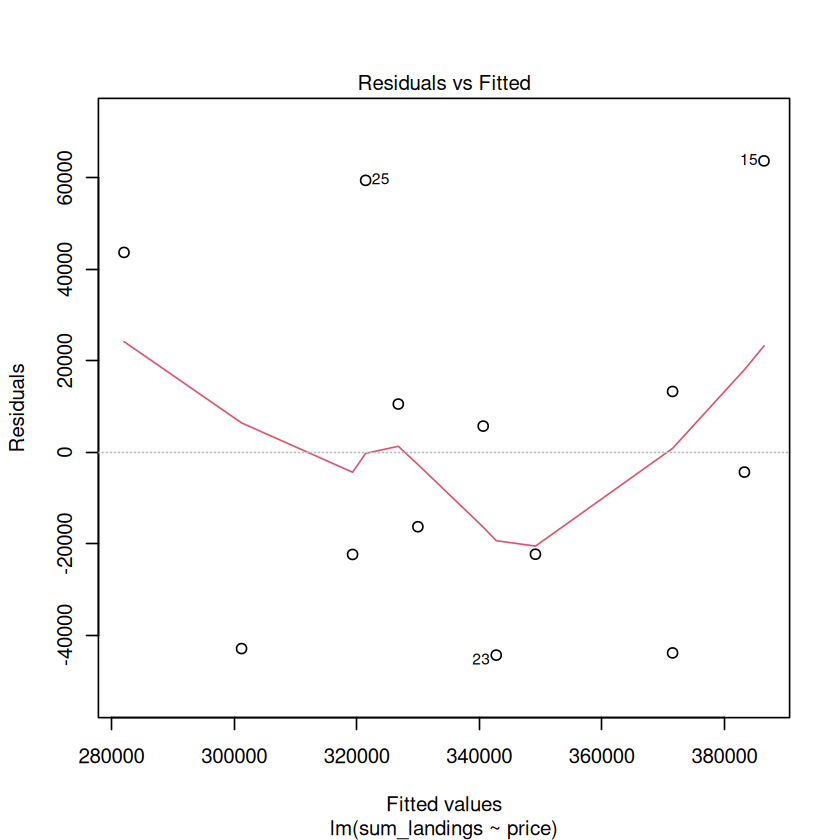

In [37]:
# Regression Analysis on Total Fish Landings and Fish Cost
landings_price_mod <- lm(sum_landings ~ price, data=landings_price)

# Print summary of results
summary(landings_price_mod)

# Plot Residuals vs Fitted
plot(landings_price_mod, 1)

## Ethical Considerations
- Privacy: The dataset does not contain personal data.
- Governance: Data used is openly available and ethically sourced.
- Bias: Consideration of potential biases in dataset and analysis.

## Acknowledging Limitations
*In 1-2 sentences, acknowledge any limitations of your data or analysis.*

Relevant Lectures:
<br>**Course 3, Module 8**: "Handling Data Anomalies" by Angel — Discusses how to handle data anomalies and understand the limitations of your data.</br>

The analysis is based on the `mpg` dataset, which may have limitations such as:
- Limited scope: Only includes data available and may not capture the entire spectrum of vehicle data.
- Data quality: Possible measurement errors or missing values.

## Results for Non-Technical Audience
*In 1-2 sentences, explain the results of your analysis to a non-technical audience and the implications of your results for your environmental topic.*

Relevant Lectures:
<br>**Course 5, Module 15**: "Turning Data into Action" by Denice Ross — Discusses strategies for communicating results to a non-technical audience.</br>

Fuel economy varies significantly across different vehicle classes. Smaller and more efficient engines generally achieve higher miles per gallon (MPG) on the highway. Manufacturers show varying performance in terms of fuel economy, with some focusing on more efficient vehicles.

## Instructions for Reproducing Project
*Describe the steps someone else would need to take to reproduce your project.*
Relevant Lectures:
<br>**Course 2, Module 6**: "Addressing Version Control and Reproducibility" by Mitch — Explains the importance and strategies for version control.</br>
<br>**Course 4, Module 14**: "Creating Data Visualizations for EDA" by JRS — Provides guidance on reproducible EDA practices.</br>

1. Clone the GitHub repository.
2. Ensure you have R and the required libraries installed (`dplyr`, `ggplot2`).
3. Open and run the provided Jupyter notebook.